# Spike Train Reproduction Post-Experiment Analysis

In [2]:
%reload_ext autoreload
%autoreload 2

# Imports
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from tqdm import tqdm
import pickle
import src.utils.preprocess as preprocess
# import src.utils.sigmoid as sigmoid
from scipy.io import savemat, loadmat
from scipy.signal import convolve2d
import re
import visionloader as vl
import sta_utils as su
from scipy.spatial import ConvexHull
import src.utils.cellmap as cellmap
import src.utils.encoding_decoding_simulation_pooled as edsp
from scipy.ndimage import gaussian_filter
from matplotlib.patches import Ellipse
from PIL import Image
import multiprocessing
from multiprocessing import Pool
import warnings

import sys
sys.path.append('/Volumes/Lab/Users/ajphillips/greedy/src/')
import sigmoid

Paths

In [3]:
piece = '2024-07-18-0'
analysis_base = f"/Volumes/Analysis/{piece}/RETINA"
pp_base = analysis_base
gsort_base = analysis_base
vstim_base = analysis_base
espont_base = analysis_base
pickle_path_base = "gsort_single_v2"

# Used response indices 8, 10, 12, 14 (second trial of moving bar in each direction) and 39-58 (first trial of jittered natural scenes for the first 20 images)
# Response index 39 is before the first image of the first trial of jittered natural scenes
frame_no = 5
response_no = 40
estim_trial = 1
label = ""
estim = f"data004/frame_{frame_no}{label}"
espont = "data004_from_data001"
vstim = "data003_from_data001"
wnoise = "data001"
cell_types = ['ON alpha', 'OFF alpha']

wnoise_path = os.path.join(analysis_base, wnoise)
pp_path = os.path.join(pp_base, estim)
gsort_path = os.path.join(gsort_base, "gsort", estim, wnoise)
vstim_path = os.path.join(vstim_base, vstim)
espont_path = os.path.join(espont_base, espont)

Single electrode scan info:

In [4]:
wn1 = 'data001'
estim1 = 'data002'
wn2 = 'data001'
estim2 = 'data005'

Load dictionary

In [5]:
# The dictionary and associated data is stored in this directory
# Much of the data/analysis associated with the experiment exists in the parent directory
dict_path = os.path.join(analysis_base, "dictionary")

# Load relevant data from .npz files
with np.load(os.path.join(dict_path,f"selective_stimuli{label}.npz")) as data:
    selective_stimuli = data["selective_stimuli"]
with np.load(os.path.join(dict_path,f"{wnoise}_bundle_thresholds.npz")) as data:
    bundle_thresholds = data["bundle_thresholds"]

print(selective_stimuli.shape)
print(bundle_thresholds.shape)

np.set_printoptions(suppress=True)
print(selective_stimuli)

(112, 4)
(512, 2)
[[   5.         6242.            1.74646017    1.        ]
 [   8.           50.            3.09322564    1.        ]
 [  17.          301.            3.03822989    1.        ]
 [  22.         6800.            2.98465253    1.        ]
 [  26.         6607.            3.56947075    1.        ]
 [  48.          406.            3.22018612    1.        ]
 [  56.         6933.            1.47567964    1.        ]
 [  70.         5328.            2.45703195    1.        ]
 [  92.          812.            1.44657868    1.        ]
 [  98.         1456.            1.77328679    1.        ]
 [ 112.          557.            1.26420075    1.        ]
 [ 115.         2207.            1.95601553    1.        ]
 [ 116.          395.            3.93191956    1.        ]
 [ 119.         5328.            3.64274917    1.        ]
 [ 128.         1906.            3.61963131    1.        ]
 [ 147.         4772.            3.22157654    1.        ]
 [ 161.         1681.            3.798

In [6]:
vcd = vl.load_vision_data(wnoise_path,wn1,
                        include_neurons=True,
                        include_ei=True,
                        include_params=True,
                        include_runtimemovie_params=True)

all_cells_of_interest = []
for cell_type in cell_types:
    all_cells_of_interest += vcd.get_all_cells_similar_to_type(cell_type)
all_cells_of_interest = np.array(all_cells_of_interest)

print(f"Total cells of type {cell_types}: {all_cells_of_interest.size}")

Total cells of type ['ON alpha', 'OFF alpha']: 75


Count the delivered stimuli

In [7]:
# The electrical stimulation scans are stored in this directory
# Much of the data/analysis associated with the experiment exists in the parent directory
path = os.path.join(analysis_base, "estim")

# Read in .mat file
ppinfo = loadmat(os.path.join(path,f"preprocessing_info{label}.mat"))
experiment_boundaries, experiment_names = ppinfo["experimentBoundaries"], ppinfo["experimentNames"]
print(f"Experiment boundaries shape {experiment_boundaries.shape}")

with open(os.path.join(path,f"spike_trains{label}.sef"), "rb") as f:
    sef = np.fromfile(f, dtype=np.int32)
    sef = np.reshape(sef, (int(len(sef)/3), 3), order='F')

sef_of_interest = sef[experiment_boundaries[frame_no,estim_trial*2+0]-1:experiment_boundaries[frame_no,estim_trial*2+1],:] # Assume 2D matrix called 'experimentBoundaries' of size |nExperiments|x|2*nBoundaries|

unique_stimuli, count_stimuli = np.unique(sef_of_interest[:,1:], axis=0, return_counts=True)
unique_times, count_times = np.unique(sef_of_interest[:,0], return_counts=True)

Experiment boundaries shape (24, 30)


In [8]:
print(f"{unique_stimuli.shape[0]} unique stimuli")
print(f"{unique_times.shape[0]} stimulation events")

print(sum(count_stimuli), "total stimulations")
print(f"Duration {(sef_of_interest[-1,0] - sef_of_interest[0,0]) / 20} ms")

60 unique stimuli
129 stimulation events
338 total stimulations
Duration 497.5 ms


### Load electrically evoked spike trains

In [9]:
def flip(cell, pattern, amp, flip_prob=0.9, plot=False):

    gsort_path_base1 = os.path.join(gsort_base, "gsort", estim1)
    gsort_path_base2 = os.path.join(gsort_base, "gsort", estim2)

    patterns = sigmoid.find_activating_patterns(gsort_path_base1, cell)
    patterns = np.sort(patterns)
    pattern_nos = [int(p.split('p')[-1]) for p in patterns]
    
    if pattern not in pattern_nos:
        raise Exception("Pattern not found in gsort_path_base1")

    pattern = f"p{pattern}"

    try:
        if plot:
            fig, ax = plt.subplots(1, 1, sharex=True, sharey=True, figsize=(5,5))

        amps1, probs1, slp1, thr1, std1, success1 = sigmoid.compute_sigmoid(gsort_path_base1, pickle_path_base, cell, pattern, plot=False)
        
        if plot:
            sigmoid.plot_sigmoid(ax, amps1, probs1, slp1, thr1, 'k')

        try:
            amps2, probs2, slp2, thr2, std2, success2 = sigmoid.compute_sigmoid(gsort_path_base2, pickle_path_base, cell, pattern) # mapping['forward'][cell]

            if plot:
                sigmoid.plot_sigmoid(ax, amps2, probs2, slp2, thr2, 'b')

        except Exception as e:
            if plot:
                ax.text(0.1,0.9,str(e))
            else:
                raise e

    except Exception as ex:
        if plot:
            ax.text(0.1,0.1,str(ex))
        else:
            raise ex
    
    if plot:
        ax.set_xlim(0,4)
        ax.set_ylim(0,1)
        ax.set_xlabel('Stimulation Amplitude (uA)')
        ax.set_ylabel('Activation Probability')
        ax.set_title(f"{piece} cell {cell} electrode {pattern[1:]}")
        plt.show()

    # Perform disambiguation
    # print(f"calibration prob {probs1[amp-1]}, bookend prob {probs2[amp-1]}, flipping {probs2[amp-1] > flip_prob}")
    if probs2[amp-1] > flip_prob:
        return True
    else:
        return False

In [10]:
def amps_to_indices(amps):
    AMPS = np.array([0.09375, 0.1875, 0.28125, 0.375, 0.46875, 0.5625, 0.65625, 0.75, 0.84375, 0.9375,
        1.03125, 1.125, 1.21875, 1.3125, 1.40625, 1.5, 1.59375, 1.6875, 1.78125, 1.875, 1.96875,
        2.0625, 2.15625, 2.25, 2.34375, 2.4375, 2.53125, 2.625, 2.71875, 2.8125, 2.90625, 3.0,
        3.09375, 3.1875, 3.28125, 3.375, 3.46875, 3.5625, 3.65625, 3.75, 3.84375, 3.9375])
    return np.array([np.argmin(np.abs(AMPS - amp)) + 1 for amp in amps]) # 1-indexed

def boolean_spikes(gsort_path_base, pickle_path_base, cell, pattern, k):
    # Set the random number seed for reproducibility of edge case behavior
    np.random.seed(cell+int(pattern[1:]))

    gsort_path = f"{gsort_path_base}/{pattern}/"
   
    pickle_path = f"{pickle_path_base}_n{cell}_{pattern}_k{k}.pkl"
    with open(gsort_path + pickle_path, 'rb') as f:
        prob_dict = pickle.load(f)
        
        cosine_prob, prob, initial_clustering_with_virtual, final_clustering, graph_info = prob_dict['cosine_prob'], prob_dict['prob'], prob_dict['initial_clustering_with_virtual'], prob_dict['final_clustering'], prob_dict['graph_info']

        cosine_prob = cosine_prob[0]
        graph_info = graph_info[2]
        final_clustering = final_clustering[0]

        # print(cosine_prob)
        # print(prob)
        # print(graph_info)
        # print(initial_clustering_with_virtual)

        if np.isclose(cosine_prob, 0, rtol=0, atol=1e-5):
            bool_spikes = [False for _ in initial_clustering_with_virtual]
            # print(bool_spikes)
            # print(sum(bool_spikes)/len(bool_spikes))
            return bool_spikes

        # get index of dictionary entry with the value cell
        edges = [*graph_info]
        edge = get_key(graph_info, cell)
        # print(edge)
        # print(edges)
        path = []
        for e in edge:
            path.extend(get_path(edges, edges.index(e)))

        # print(path)

        if np.isclose(cosine_prob, prob, rtol=0, atol=1e-5):
            bool_spikes = [spike in path for spike in initial_clustering_with_virtual]
            # print(bool_spikes)
            # print(sum(bool_spikes)/len(bool_spikes))
            return bool_spikes
        

        all_possible_edges = []
        difference = np.round(np.abs(cosine_prob - prob)*len(initial_clustering_with_virtual)).astype(int)
        # print(difference)

        for e in edge:
            _ = find_cosine_path(edges, edges.index(e), initial_clustering_with_virtual, all_possible_edges, difference)
        # print(all_possible_edges)

        if len(all_possible_edges) > 1:
            warnings.warn("Ambiguous cosine similarity single path removal") # we cannot infer which edge was removed, arbitrarily guess the first one
        elif len(all_possible_edges) == 0:
            warnings.warn("No valid cosine similarity single path removal") # indicating multiple edges have been removed, randomly assign the spikes
            
            # Build a randomly shuffled list of booleans corresponding to the cosine probability
            bool_spikes = [True if i < np.round(cosine_prob*len(initial_clustering_with_virtual)).astype(int) else False for i in range(len(initial_clustering_with_virtual))]
            np.random.shuffle(bool_spikes)

            # print(bool_spikes)
            # print(sum(bool_spikes)/len(bool_spikes))
            return bool_spikes
        
        removal_path = get_path(edges, edges.index(all_possible_edges[0]))
        # print(removal_path)

        bool_spikes = [spike in path and spike not in removal_path for spike in initial_clustering_with_virtual]
        # print(bool_spikes)
        # print(sum(bool_spikes)/len(bool_spikes))
        
        return bool_spikes


def get_key(my_dict, val):
    keys = []
   
    for key, value in my_dict.items():
        if val == value:
            keys.append(key)

    if len(keys) == 0:
        raise ValueError("Cell not assigned to any edge")

    return keys

def get_path(edges, start_index):
    path = []
    path.append(edges[start_index][1])

    for i in range(len(edges)):
        if edges[i][0] == edges[start_index][1]:
            path.extend(get_path(edges, i))

    return path
    
def find_cosine_path(edges, start_index, initial_clustering_with_virtual, all_possible_edges, difference):

    count = 0
    for i in range(len(edges)):
        if edges[i][0] == edges[start_index][1]:
            count += find_cosine_path(edges, i, initial_clustering_with_virtual, all_possible_edges, difference)
    
    total = np.sum(edges[start_index][1] == initial_clustering_with_virtual) + count
    if total == difference:
        all_possible_edges.append(edges[start_index])
    return total


In [11]:
spikes = {}
probabilities = {}

initial_spikes = {}
initial_probabilities = {}


for t in tqdm(range(unique_times.shape[0])):
    # print(f"PATTERN {t+1}")

    # Set up nested dictionaries
    initial_spikes[t] = {}
    initial_probabilities[t] = {}
    spikes[t] = {}
    probabilities[t] = {}

    # Identify all electrical stimuli delivered simultaneously at time t
    stim = sef_of_interest[np.where(sef_of_interest[:,0] == unique_times[t])[0],1:]

    for s in stim:

        # Find the row of selective_stimuli corresponding to each electrical stimulus
        selective_stimulus = selective_stimuli[np.where((selective_stimuli[:,0] == s[0]) & (amps_to_indices(selective_stimuli[:,2]) == s[1]))[0][0]]
        # print(selective_stimulus)

        # Look for electrical spike sorting results at the time-pattern for each targeted cell (only ever one movie per time-pattern)
        c = int(selective_stimulus[1])
        # print(f"Cell {c}")
        bs = boolean_spikes(gsort_path, pickle_path_base, c, f"p{t+1}", 0)

        initial_spikes[t][c] = bs
        initial_probabilities[t][c] = np.mean(bs)

        # print(bs)
        # print(np.mean(bs))

        # If the selective stimulus was pure (we expected the cell to spike with ~100% probability) and gsort returns ~0% probability,
        # cross reference with the bookend single-electrode scan to decide how to disambiguate
        # Assumes that multi-electrode stimulation does not significantly alter the single-electrode activation curve
        # Ask Amrith about explanation for 0.1
        # _ = flip(c, s[0], s[1], flip_prob=0.9, plot=True)

        if int(selective_stimulus[3]) and (np.mean(bs) < 0.1): 
            if flip(c, s[0], s[1], flip_prob=0.9, plot=False): 
                bs = [not b for b in bs]

        spikes[t][c] = bs
        probabilities[t][c] = np.mean(bs)

    #     print(bs)
    #     print(np.mean(bs))

    # print("=================================")


 25%|██▍       | 32/129 [02:13<12:07,  7.50s/it] /tmp/ipykernel_6009/912500474.py:62: UserWarning: Ambiguous cosine similarity single path removal
  warnings.warn("Ambiguous cosine similarity single path removal") # we cannot infer which edge was removed, arbitrarily guess the first one
100%|██████████| 129/129 [06:08<00:00,  2.85s/it]


### Load visually evoked spike trains

In [12]:
vstim_vcd = vl.load_vision_data(vstim_path,vstim,
                                include_neurons=True)

selective_cells_of_interest = np.unique(selective_stimuli[:,1]).astype(int)
print(f"Total selective cells of type {cell_types}: {selective_cells_of_interest.size}")

# Order selective_cells_of_interest by STA center from leftmost to rightmost
sta_centers = []
for c in selective_cells_of_interest:
        center_x = vcd.get_stafit_for_cell(c).center_x
        center_y = int(vcd.get_runtimemovie_params().height) - vcd.get_stafit_for_cell(c).center_y
        sta_centers.append([center_x, center_y])
sta_centers = np.array(sta_centers)

# Sort left to right
# selective_cells_of_interest = selective_cells_of_interest[np.argsort(sta_centers[:,0])]

# Sort right to left
# selective_cells_of_interest = selective_cells_of_interest[np.argsort(sta_centers[:,0])[::-1]]

# Sort bottom to top
selective_cells_of_interest = selective_cells_of_interest[np.argsort(sta_centers[:,1])]

# Sort top to bottom
# selective_cells_of_interest = selective_cells_of_interest[np.argsort(sta_centers[:,1])[::-1]]


spike_times = np.array([vstim_vcd.get_spike_times_for_cell(c) for c in selective_cells_of_interest], dtype=object) / 20 # convert to ms

ttl_times = vstim_vcd.ttl_times / 20 # convert to ms

responses = []
for j in range(len(ttl_times)-1):
    low = ttl_times[j]
    high = ttl_times[j+1]
    filtered_spike_times = np.array([spike_time[(low < spike_time) & (spike_time < high)] for spike_time in spike_times], dtype=object)
    responses.append(filtered_spike_times)

Total selective cells of type ['ON alpha', 'OFF alpha']: 53


In [13]:
# Make sure this index agrees with the frame you are looking at
response = responses[response_no]

In [14]:
# Build electrically evoked response for a single trial using the spike dictionary
estim_response = [[] for _ in range(len(selective_cells_of_interest))]

for t in range(unique_times.shape[0]):
    for c in spikes[t]:
        if spikes[t][c][estim_trial]:
            estim_response[np.where(selective_cells_of_interest == c)[0][0]].append(unique_times[t])

for c in range(len(estim_response)):
    estim_response[c] = np.array(estim_response[c])
estim_response = np.array(estim_response, dtype=object) / 20 # convert to ms

In [15]:
# Align response rasters in time (the very first attempted estim is aligned with the very first rounded recorded vstim spike)
bin_size_ms = 2.5
rounded_response = np.array([np.round(cell_spike_times / bin_size_ms) * bin_size_ms for cell_spike_times in response], dtype=object)

response_reference_candidates = []
for c in range(len(rounded_response)):
    if len(rounded_response[c]) > 0:
        response_reference_candidates.append(rounded_response[c][0])
response_reference = np.min(response_reference_candidates)
print(f"response reference time: {response_reference}")


estim_response_reference = sef_of_interest[0,0] / 20 # convert to ms
print(f"estim response reference time: {estim_response_reference}")

response reference time: 150532.5
estim response reference time: 462000.05


### Add spontaneous activity to electrically evoked spike trains

In [16]:
espont_vcd = vl.load_vision_data(espont_path,espont,
                                include_neurons=True)

espont_spike_times = np.array([espont_vcd.get_spike_times_for_cell(c) for c in selective_cells_of_interest], dtype=object)

offset = 20000 # offset of 20000 samples between SEF times and actual data
low = unique_times[0] + offset
high = unique_times[-1] + offset
total_response = np.array([(spike_time[(low < spike_time) & (spike_time < high)] - offset) / 20 for spike_time in espont_spike_times], dtype=object) # convert to ms

In [17]:
print(f"All spikes found by Vision are")
for c in range(len(total_response)):
    print(f"Cell {selective_cells_of_interest[c]} spikes: {len(total_response[c])}")

All spikes found by Vision are
Cell 3781 spikes: 0
Cell 4683 spikes: 1
Cell 5926 spikes: 5
Cell 4021 spikes: 1
Cell 5163 spikes: 0
Cell 4204 spikes: 1
Cell 5989 spikes: 0
Cell 4322 spikes: 0
Cell 6061 spikes: 0
Cell 4878 spikes: 0
Cell 3443 spikes: 1
Cell 6081 spikes: 0
Cell 3516 spikes: 1
Cell 5491 spikes: 1
Cell 3991 spikes: 2
Cell 4772 spikes: 3
Cell 6020 spikes: 3
Cell 3226 spikes: 0
Cell 3451 spikes: 1
Cell 4051 spikes: 0
Cell 3181 spikes: 0
Cell 5032 spikes: 0
Cell 6303 spikes: 0
Cell 3166 spikes: 1
Cell 6587 spikes: 1
Cell 6242 spikes: 0
Cell 4249 spikes: 1
Cell 6530 spikes: 0
Cell 3077 spikes: 0
Cell 1681 spikes: 13
Cell 6607 spikes: 0
Cell 1804 spikes: 0
Cell 6634 spikes: 0
Cell 5328 spikes: 6
Cell 6800 spikes: 0
Cell 1456 spikes: 0
Cell 7066 spikes: 2
Cell 6933 spikes: 2
Cell 301 spikes: 1
Cell 5537 spikes: 3
Cell 6952 spikes: 0
Cell 395 spikes: 0
Cell 812 spikes: 2
Cell 6961 spikes: 1
Cell 2207 spikes: 14
Cell 7234 spikes: 0
Cell 557 spikes: 2
Cell 406 spikes: 0
Cell 5687 sp

In [52]:
# Get rid of any electrically evoked spikes identified by Vision
espont_response = [[] for _ in range(len(total_response))]
for c in range(len(total_response)):
    espont_response[c] = np.array([spike for spike in total_response[c] if not np.any(((spike - estim_response[c]) >= 0) & ((spike - estim_response[c]) <= 2))])
espont_response = np.array(espont_response, dtype=object)

In [53]:
print(f"Spontaneous spikes found by Vision are")
for c in range(len(espont_response)):
    print(f"Cell {selective_cells_of_interest[c]} spikes: {len(espont_response[c])}")

Spontaneous spikes found by Vision are
Cell 3781 spikes: 0
Cell 4683 spikes: 1
Cell 5926 spikes: 5
Cell 4021 spikes: 1
Cell 5163 spikes: 0
Cell 4204 spikes: 0
Cell 5989 spikes: 0
Cell 4322 spikes: 0
Cell 6061 spikes: 0
Cell 4878 spikes: 0
Cell 3443 spikes: 1
Cell 6081 spikes: 0
Cell 3516 spikes: 1
Cell 5491 spikes: 1
Cell 3991 spikes: 2
Cell 4772 spikes: 3
Cell 6020 spikes: 2
Cell 3226 spikes: 0
Cell 3451 spikes: 1
Cell 4051 spikes: 0
Cell 3181 spikes: 0
Cell 5032 spikes: 0
Cell 6303 spikes: 0
Cell 3166 spikes: 1
Cell 6587 spikes: 1
Cell 6242 spikes: 0
Cell 4249 spikes: 0
Cell 6530 spikes: 0
Cell 3077 spikes: 0
Cell 1681 spikes: 0
Cell 6607 spikes: 0
Cell 1804 spikes: 0
Cell 6634 spikes: 0
Cell 5328 spikes: 3
Cell 6800 spikes: 0
Cell 1456 spikes: 0
Cell 7066 spikes: 0
Cell 6933 spikes: 1
Cell 301 spikes: 1
Cell 5537 spikes: 3
Cell 6952 spikes: 0
Cell 395 spikes: 0
Cell 812 spikes: 2
Cell 6961 spikes: 1
Cell 2207 spikes: 0
Cell 7234 spikes: 0
Cell 557 spikes: 2
Cell 406 spikes: 0
Cell 5

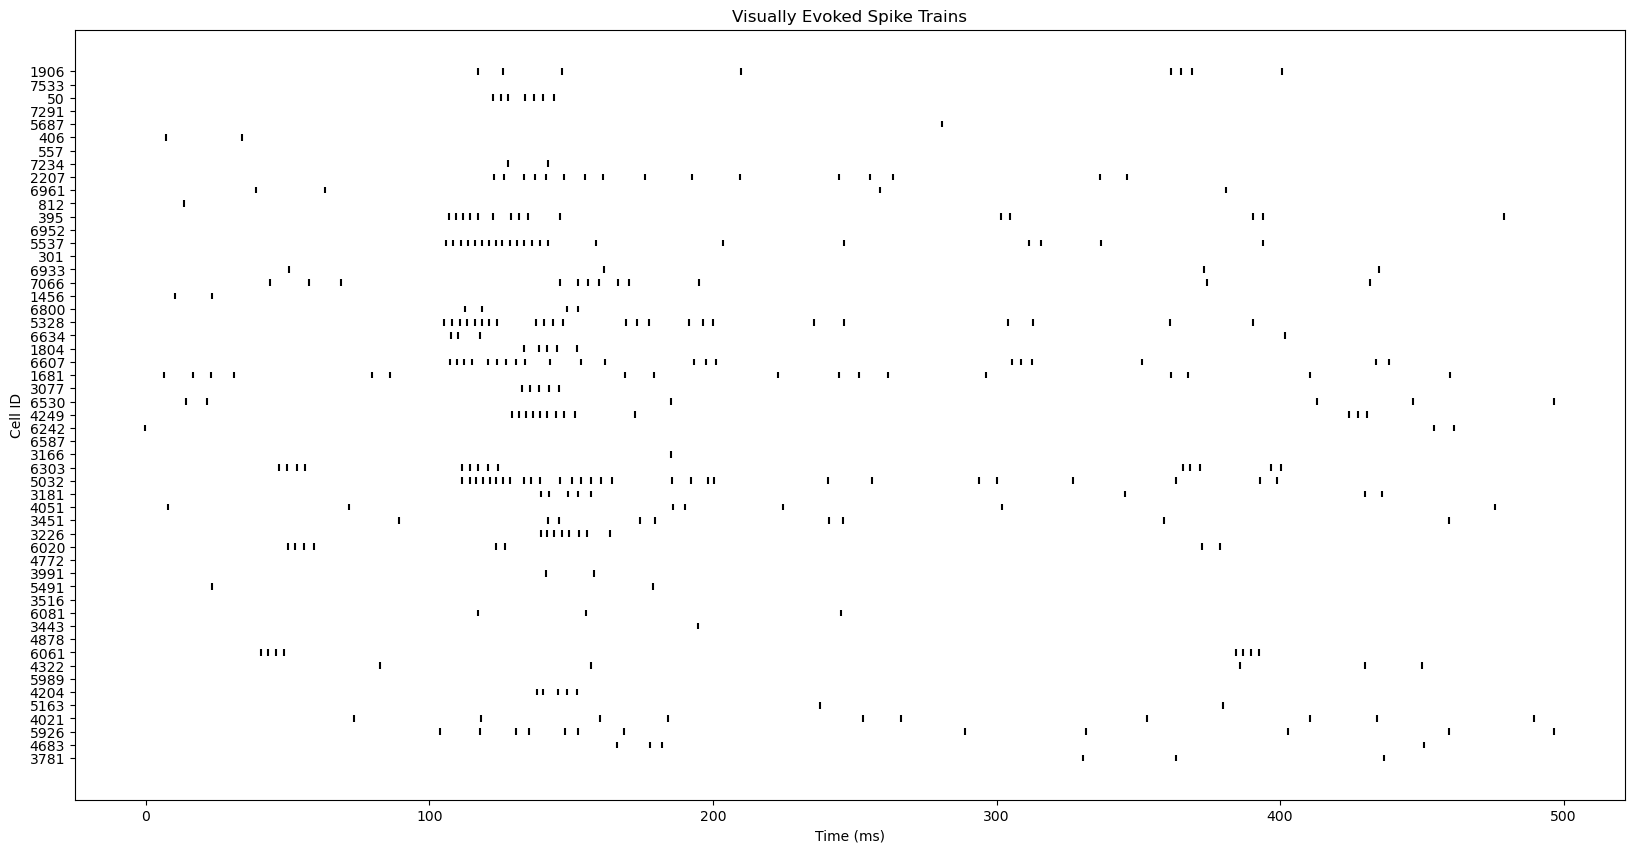

In [54]:
plt.figure(figsize=(20, 10))

# Create a spike raster plot
plt.eventplot(response-response_reference, linelengths=0.5, colors='black')

# Set the y-axis ticks and labels
plt.yticks(range(len(selective_cells_of_interest)), selective_cells_of_interest)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Visually Evoked Spike Trains')

# Show the plot
plt.show()

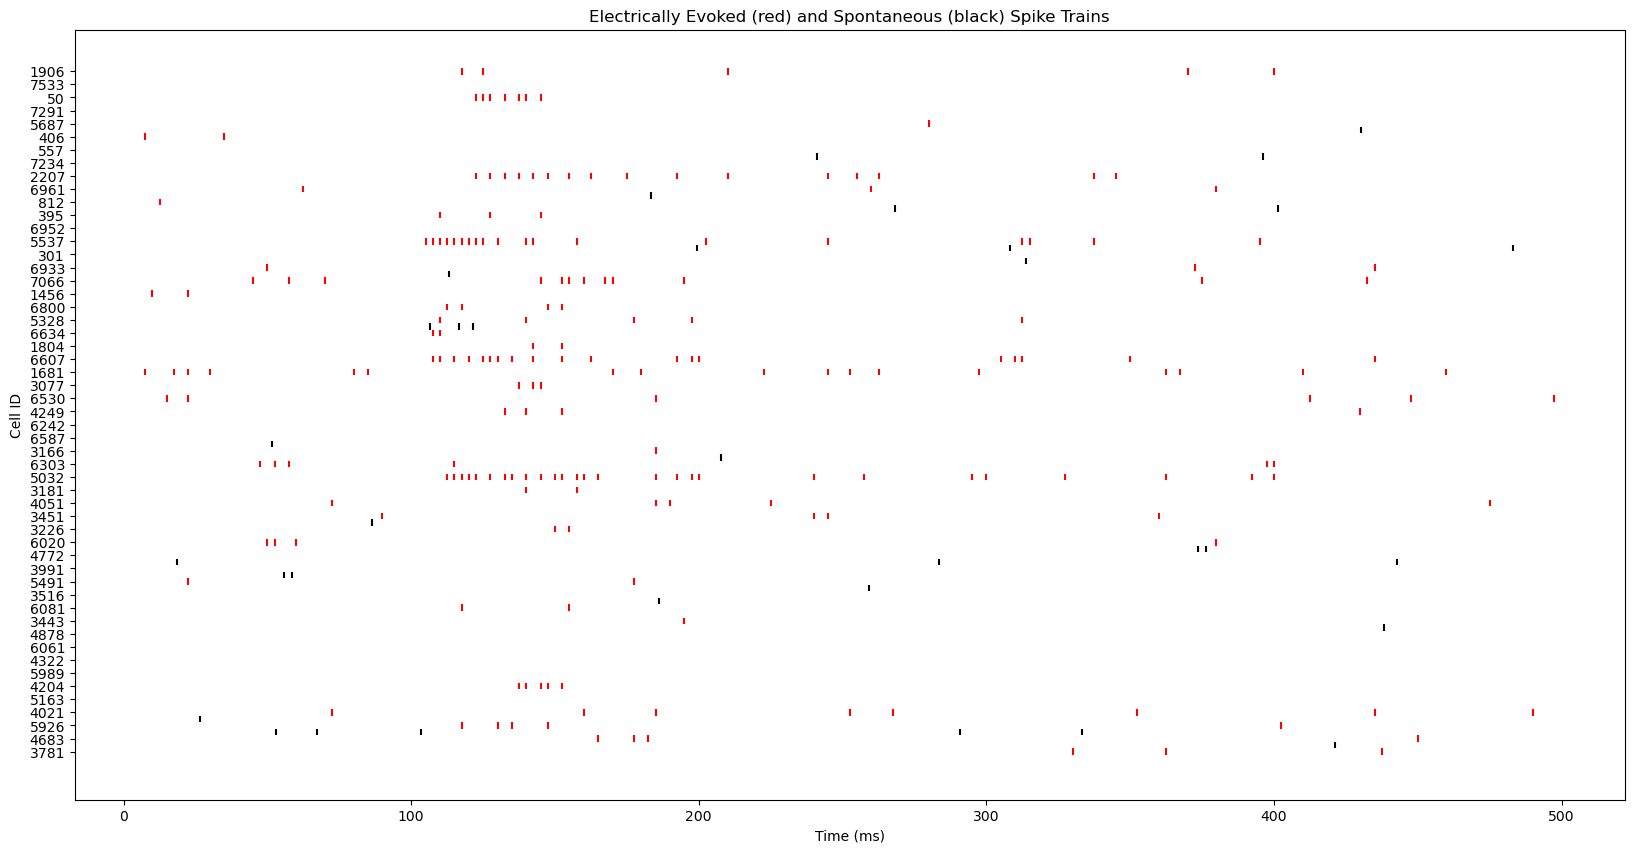

In [55]:
plt.figure(figsize=(20, 10))

# Make two lineoffsets vectors offset by a constant value
lineoffsets1 = np.arange(len(selective_cells_of_interest))
lineoffsets2 = np.arange(len(selective_cells_of_interest)) - 0.5

# Create a spike raster plot
plt.eventplot(estim_response-estim_response_reference, linelengths=0.5, lineoffsets=lineoffsets1, colors='red')
plt.eventplot(espont_response-estim_response_reference, linelengths=0.5, lineoffsets=lineoffsets2, colors='black')

# plt.eventplot(estim_response-estim_response_reference, linelengths=0.5, colors='red')
# plt.eventplot(espont_response-estim_response_reference, linelengths=0.5, colors='red')

# Set the y-axis ticks and labels
plt.yticks(range(len(selective_cells_of_interest)), selective_cells_of_interest)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Electrically Evoked (red) and Spontaneous (black) Spike Trains')

# Restrict the x axis
# plt.xlim(2000, 3000)

# Show the plot
plt.show()

### Put it all together and make the money figure

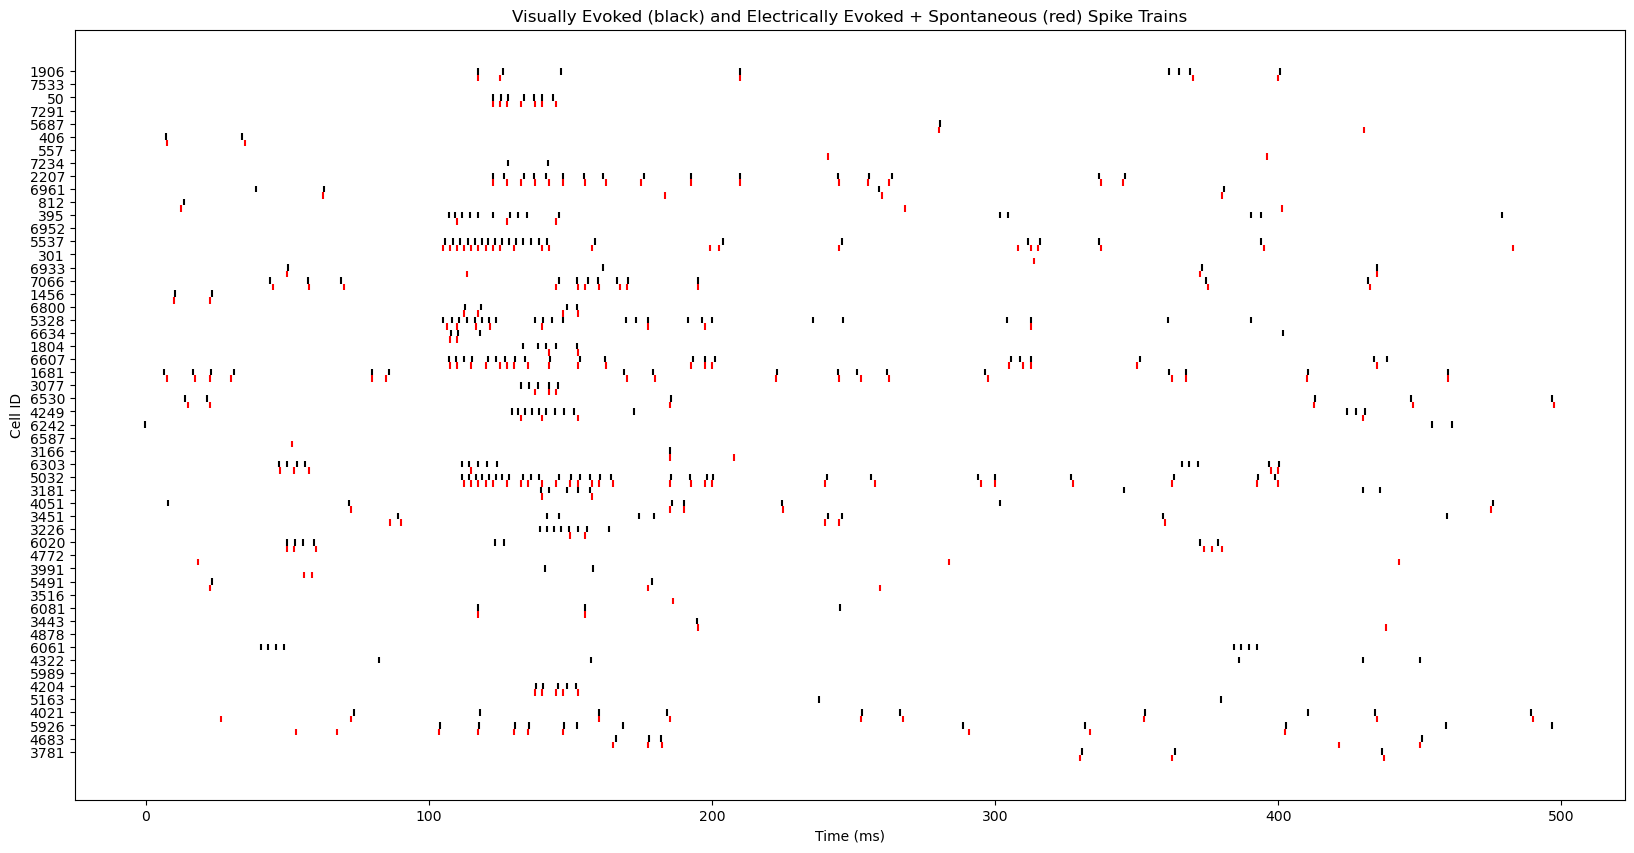

In [56]:
plt.figure(figsize=(20, 10))

# Make two lineoffsets vectors offset by a constant value
lineoffsets1 = np.arange(len(selective_cells_of_interest))
lineoffsets2 = np.arange(len(selective_cells_of_interest)) - 0.5

# Create a spike raster plot
plt.eventplot(response-response_reference, linelengths=0.5, lineoffsets=lineoffsets1, colors='black')
plt.eventplot(estim_response-estim_response_reference, linelengths=0.5, lineoffsets=lineoffsets2, colors='red')
plt.eventplot(espont_response-estim_response_reference, linelengths=0.5, lineoffsets=lineoffsets2, colors='red')

# Set the y-axis ticks and labels
plt.yticks(range(len(selective_cells_of_interest)), selective_cells_of_interest)
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Visually Evoked (black) and Electrically Evoked + Spontaneous (red) Spike Trains')

# Restrict the x axis
# plt.xlim(2000, 3000)

# Show the plot
plt.show()

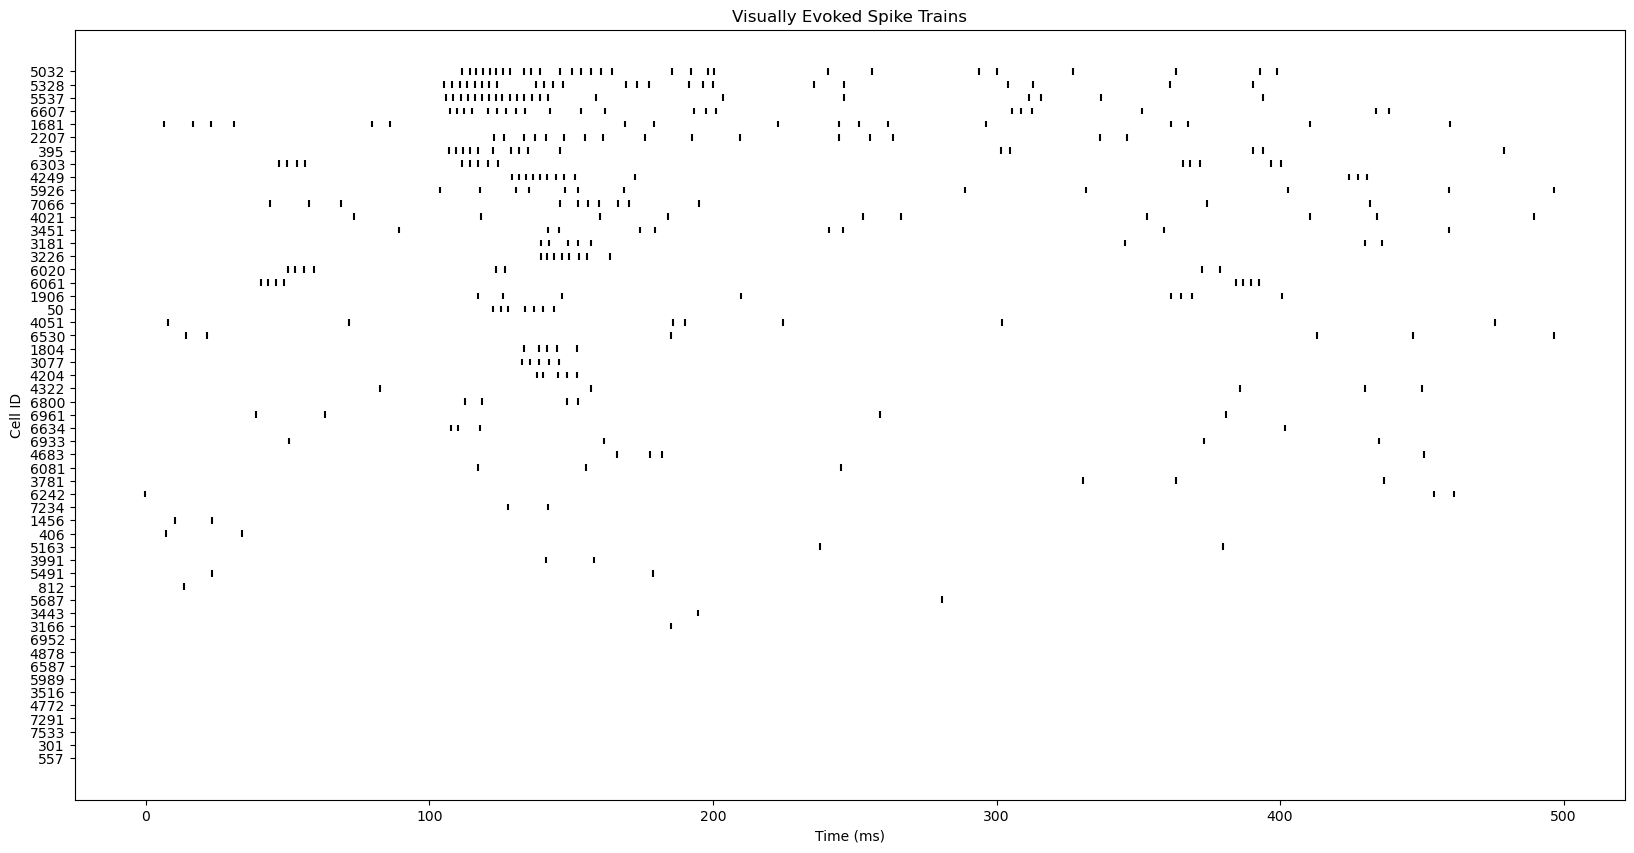

In [57]:
# Sort by number of spikes in the visually evoked response
sorted_cells = np.argsort([len(cell_spikes) for cell_spikes in response])

plt.figure(figsize=(20, 10))

# Create a spike raster plot
plt.eventplot(np.array([response[i]-response_reference for i in sorted_cells], dtype=object), linelengths=0.5, colors='black')

# Set the y-axis ticks and labels
plt.yticks(range(len(selective_cells_of_interest)), selective_cells_of_interest[sorted_cells])

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Visually Evoked Spike Trains')
plt.ylabel('Cell ID')

# Show the plot
plt.show()

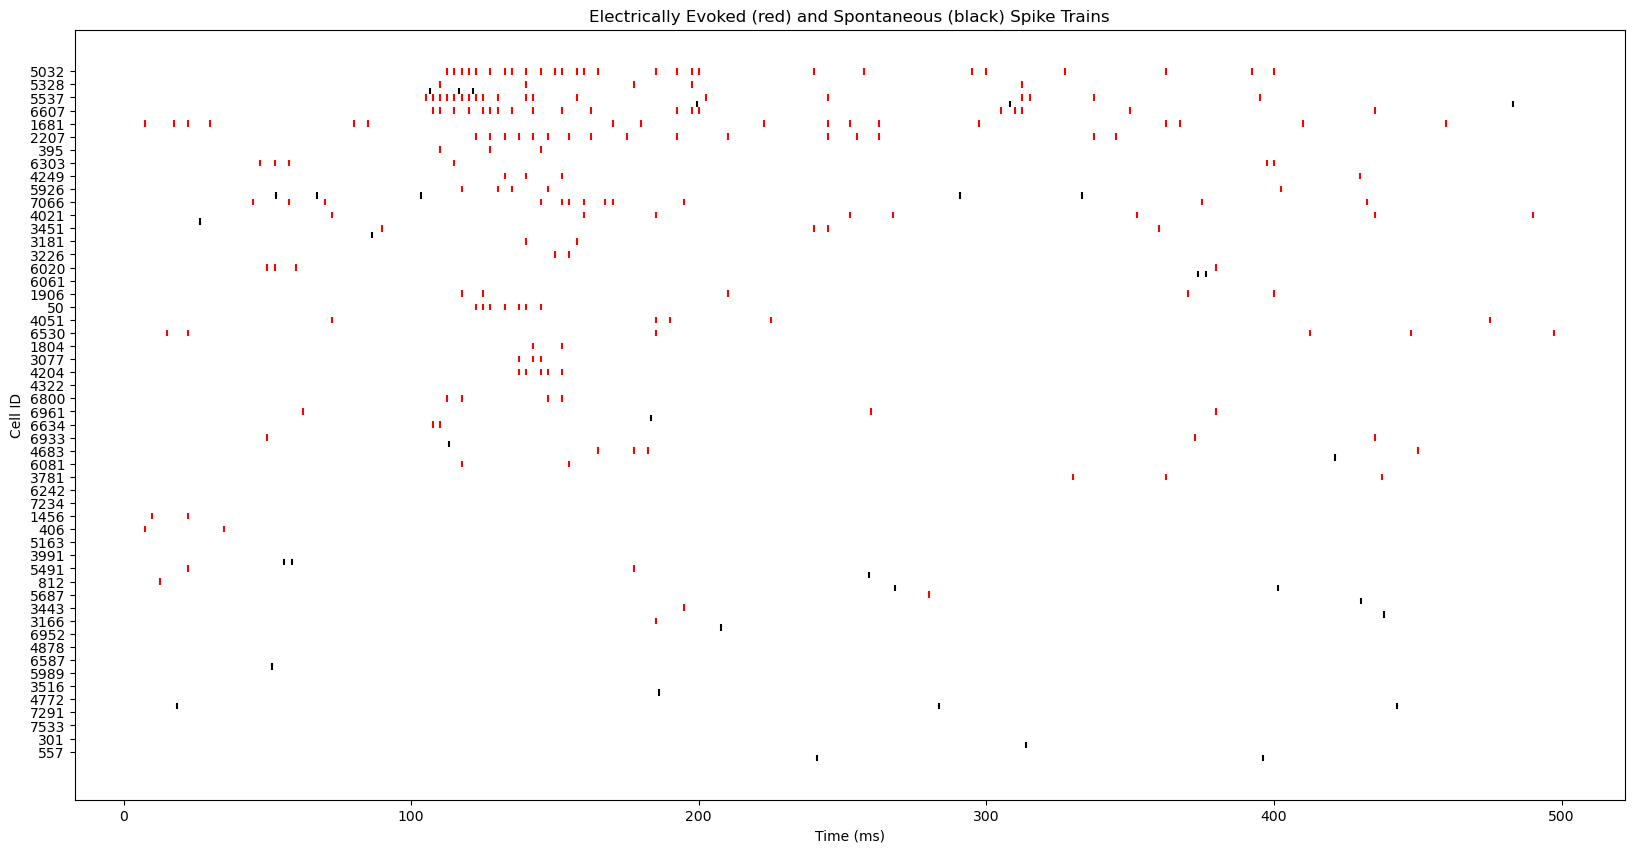

In [58]:
plt.figure(figsize=(20, 10))

# Make two lineoffsets vectors offset by a constant value
lineoffsets1 = np.arange(len(selective_cells_of_interest))
lineoffsets2 = np.arange(len(selective_cells_of_interest)) - 0.5

# Create a spike raster plot
plt.eventplot(np.array([estim_response[i]-estim_response_reference for i in sorted_cells], dtype=object), linelengths=0.5, lineoffsets=lineoffsets1, colors='red')
plt.eventplot(np.array([espont_response[i]-estim_response_reference for i in sorted_cells], dtype=object), linelengths=0.5, lineoffsets=lineoffsets2, colors='black')

# plt.eventplot(np.array([estim_response[i]-estim_response_reference for i in sorted_cells], dtype=object), linelengths=0.5, colors='red')
# plt.eventplot(np.array([espont_response[i]-estim_response_reference for i in sorted_cells], dtype=object), linelengths=0.5, colors='red')

# Set the y-axis ticks and labels
plt.yticks(range(len(selective_cells_of_interest)), selective_cells_of_interest[sorted_cells])
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Electrically Evoked (red) and Spontaneous (black) Spike Trains')

# Restrict the x axis
# plt.xlim(2000, 3000)

# Show the plot
plt.show()

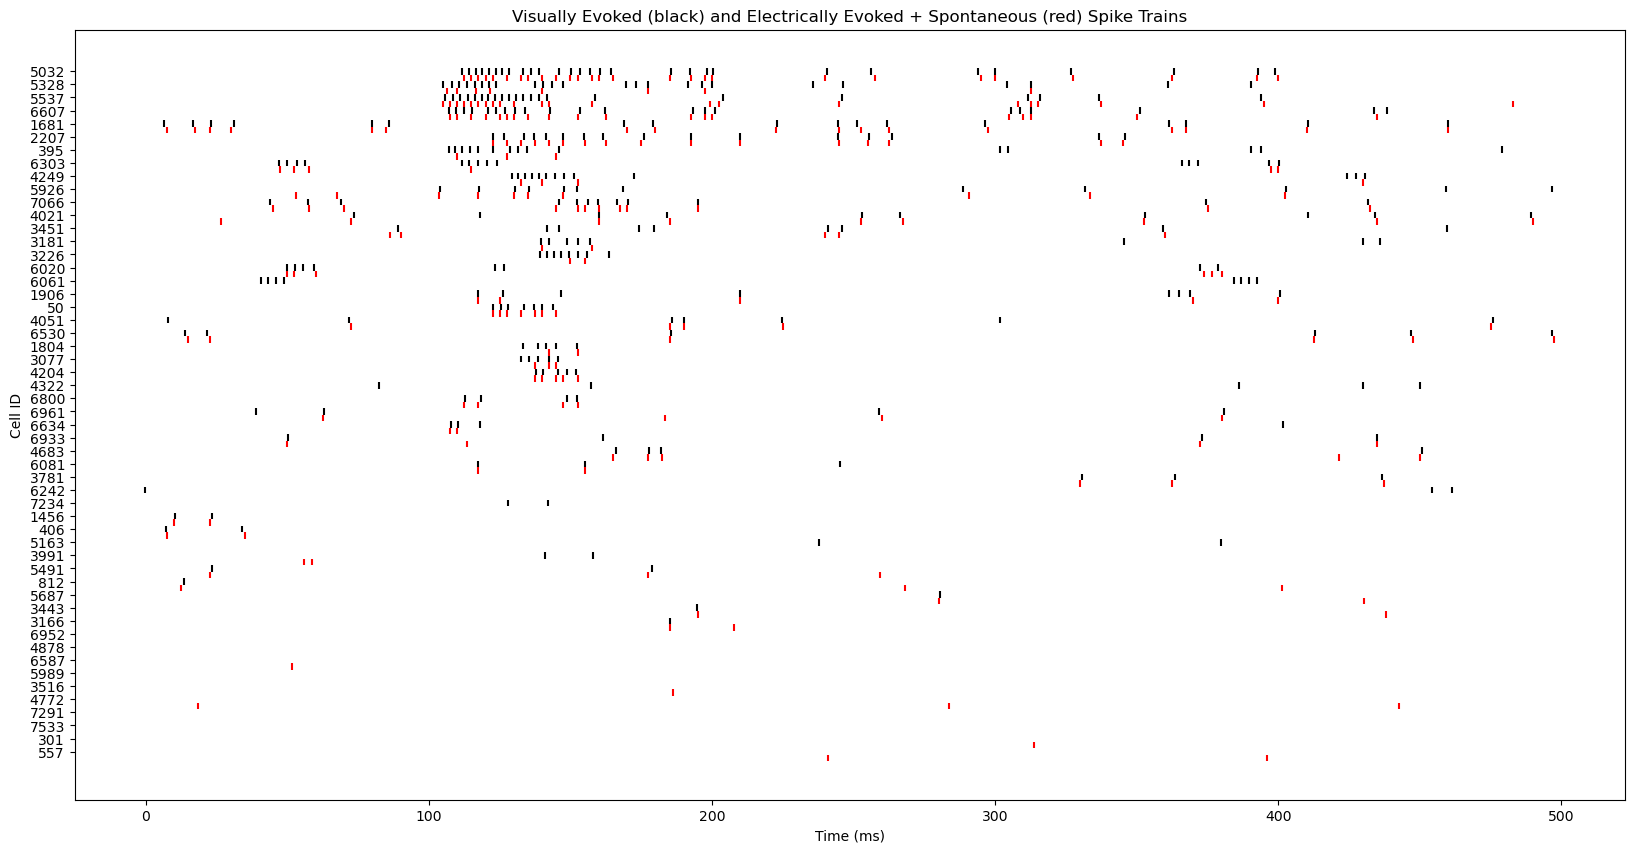

In [59]:
plt.figure(figsize=(20, 10))

# Make two lineoffsets vectors offset by a constant value
lineoffsets1 = np.arange(len(selective_cells_of_interest))
lineoffsets2 = np.arange(len(selective_cells_of_interest)) - 0.5

# Create a spike raster plot
plt.eventplot(np.array([response[i]-response_reference for i in sorted_cells], dtype=object), linelengths=0.5, lineoffsets=lineoffsets1, colors='black')
plt.eventplot(np.array([estim_response[i]-estim_response_reference for i in sorted_cells], dtype=object), linelengths=0.5, lineoffsets=lineoffsets2, colors='red')
plt.eventplot(np.array([espont_response[i]-estim_response_reference for i in sorted_cells], dtype=object), linelengths=0.5, lineoffsets=lineoffsets2, colors='red')

# Set the y-axis ticks and labels
plt.yticks(range(len(selective_cells_of_interest)), selective_cells_of_interest[sorted_cells])
plt.ylabel('Cell ID')

# Set the x-axis label
plt.xlabel('Time (ms)')

# Set the plot title
plt.title('Visually Evoked (black) and Electrically Evoked + Spontaneous (red) Spike Trains')

# Restrict the x axis
# plt.xlim(2000, 3000)

# Show the plot
plt.show()